# Unit 1 Assessment: Dataset 4 — Online Retail Transaction Analysis

## Part 2 — Investigate and Visualise

### Transitional handover from Part 1

After a titanic struggle and much soul searching, the first notebook established the evidence base for this analysis. It inspected the raw transaction file before filtering, documented the cleaning decisions, retained excluded rows for audit, matched the cancellation lines that could be resolved safely, created the business measures, and validated the resulting paid-product table.

This notebook begins at that hand-off rather than relying on my previous plan of an open notebook session. I reload the saved clean table, verify that it is the expected output, and restore the date type needed for time-based analysis. If that checkpoint fails, the right response is to return to Part 1 and resolve the hand-off—not to continue analysing an uncertain file.

From this point, the questions become more focused, more commercial and exploratory: which products generate recorded revenue, which markets are busy or valuable, and how does recorded revenue change through the observed year? I display the relevant table or metric before each chart so that every visualisation answers a visible question and every conclusion stays within the evidence.

The analysis remains descriptive. `Revenue` means recorded line revenue (`Quantity × UnitPrice`) in the cleaned paid-product scope; it is not profit, margin, or proof of causation.

I retain a simple philosophy to guide me in this:

> *For every analysis cell, write the human question and metric in the Markdown above it.*
>
> *A chart is not a question nor an answer by itself.*
>
> *Question first → data shape → chart type → useful parameters → explain the result.*

### Handover checkpoint — reload and verify the Part 1 output

The CSV format does not retain every in-memory type from Part 1. This small setup step therefore reloads the validated file, parses `InvoiceDate`, restores useful text types, and checks the hand-off before any investigation begins.

In [1]:
# I reload the validated Part 1 hand-off instead of relying on hidden kernel state.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

cleaned_path = Path("../outputs/cleaned_online_retail.csv")
df_clean = pd.read_csv(cleaned_path, parse_dates=["InvoiceDate"])

# CSV stores these fields as ordinary text; restoring string types keeps later grouping and labels explicit.
for column in ["InvoiceNo", "StockCode", "Description", "Country", "Month", "DayOfWeek"]:
    df_clean[column] = df_clean[column].astype("string")

required_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate",
    "UnitPrice", "CustomerID", "Country", "Revenue", "Month", "DayOfWeek",
]
missing_columns = [column for column in required_columns if column not in df_clean.columns]
expected_rows = 521_913

print("Loaded:", cleaned_path)
print("Shape:", df_clean.shape)
print("InvoiceDate dtype:", df_clean["InvoiceDate"].dtype)
print("Missing required columns:", missing_columns)

if missing_columns:
    raise ValueError(f"The Part 1 hand-off is missing columns: {missing_columns}")
if len(df_clean) != expected_rows:
    raise ValueError(
        f"Unexpected hand-off row count: {len(df_clean)}; expected {expected_rows}. "
        "Return to Part 1 and review the saved output before continuing."
    )

display(df_clean.head())

Loaded: ../outputs/cleaned_online_retail.csv
Shape: (521913, 11)
InvoiceDate dtype: datetime64[us]
Missing required columns: []


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday


### Consequence — the Part 1 hand-off passed its checkpoint

The output confirms that the validated table has loaded with 521,913 rows, all required columns, and parsed invoice dates. This is the stable paid-product scope for Part 2, so I can now ask the first product question.

# Phase 4 — answer three focused business questions

### Question 1 — which products generate recorded revenue?

Product performance first. I calculate recorded revenue by product and look at the highest-revenue rows before I go anywhere near the chart. This answers a product-performance question — nothing here claims to know profit or margin, because the data simply doesn't carry either.

In [2]:
# I group line revenue by product and keep the ten largest totals for the first question.
product_revenue = (
    df_clean.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(product_revenue)

,StockCode,Description,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,172847.04
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,102973.84
2,47566,PARTY BUNTING,99425.43
3,85099B,JUMBO BAG RED RETROSPOT,92862.13
4,23084,RABBIT NIGHT LIGHT,66857.55
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64038.94
6,84879,ASSORTED COLOUR BIRD ORNAMENT,58905.65
7,79321,CHILLI LIGHTS,53767.36
8,23298,SPOTTY BUNTING,42513.48
9,22386,JUMBO BAG PINK POLKADOT,41656.01


### Consequence — top-product revenue is quantified

The table identifies the ten products with the largest recorded revenue, led by Regency Cakestand 3 Tier and White Hanging Heart T-Light Holder. The ranking gives me a concrete product set to show visually next.

### Chart — top products by recorded revenue

Seaborn does the heavy lifting here, and I don't think I can express how much I love Seaborn.  It is simply the most fantastic tool to be built on top of matplotlib. It is so intuitive. I will use it to turn the product comparison into something readable at a glance. What I describe below sticks strictly to the products and revenue values actually visible in the table and chart — nothing inferred beyond that.

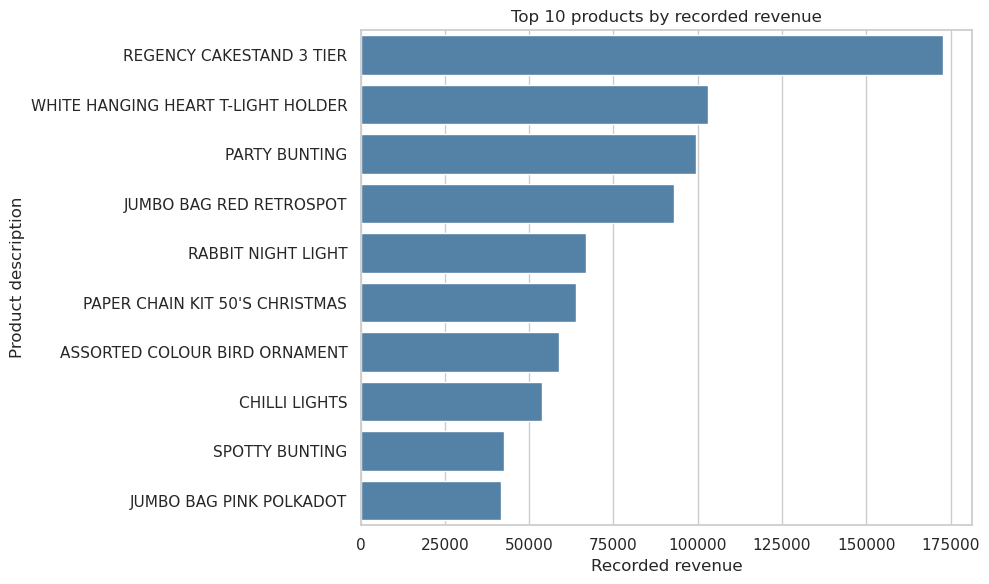

In [3]:
# I use Seaborn to compare the products shown in the table.
plt.figure(figsize=(10, 6))
sns.barplot(data=product_revenue, x="Revenue", y="Description", color="steelblue")
plt.title("Top 10 products by recorded revenue")
plt.xlabel("Recorded revenue")
plt.ylabel("Product description")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_top_products_by_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### Consequence — the UK-wide product ranking is visible

The chart makes the leading products and their relative recorded revenue easy to compare. Because UK rows dominate this view, the next step repeats the same product question with the UK removed rather than allowing the scale to hide international demand.

### Question 1A — which products lead outside the UK?

To compare international product demand directly, I build a second view with the UK stripped away.

Worth being clear: this is a viewing choice, not a cleaning one. The UK rows haven't gone anywhere — they're still sitting in `df_clean`, still counting towards everything else, but the dominance of their visual presence rendered everything else outside them compressed, if not inconsequential.

,StockCode,Description,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,31682.55
1,23084,RABBIT NIGHT LIGHT,28877.04
2,22326,ROUND SNACK BOXES SET OF4 WOODLAND,18469.15
3,22629,SPACEBOY LUNCH BOX,14468.85
4,22630,DOLLY GIRL LUNCH BOX,12595.35
5,22328,ROUND SNACK BOXES SET OF 4 FRUITS,12261.50
6,21731,RED TOADSTOOL LED NIGHT LIGHT,10491.75
7,23245,SET OF 3 REGENCY CAKE TINS,8520.95
8,84997D,CHILDRENS CUTLERY POLKADOT PINK,8193.45
9,22720,SET OF 3 CAKE TINS PANTRY DESIGN,8190.45


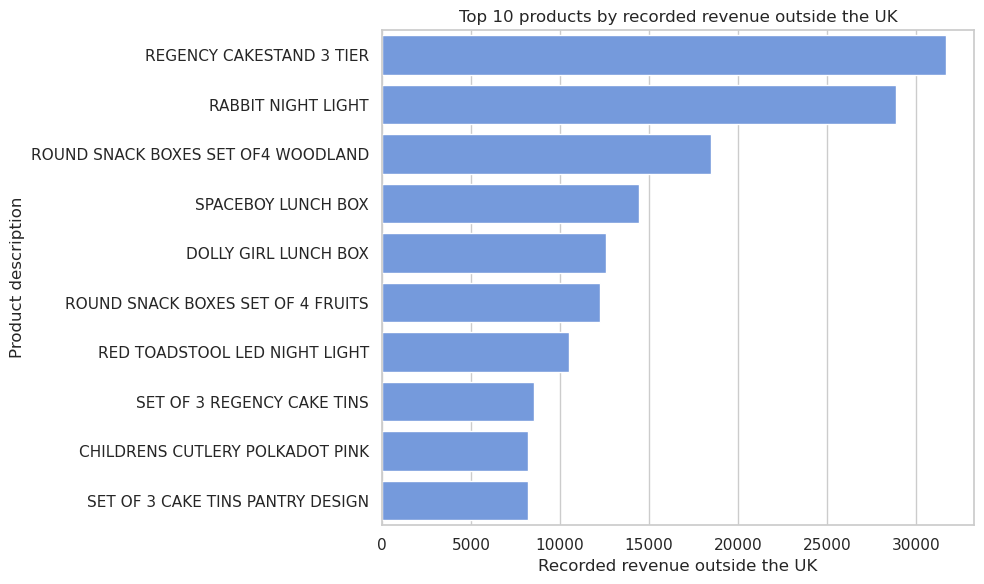

In [4]:
# I create an international comparison view without changing the clean table.
df_non_uk = df_clean[df_clean["Country"] != "United Kingdom"].copy()

# I calculate the highest recorded-revenue products outside the UK.
non_uk_product_revenue = (
    df_non_uk.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(non_uk_product_revenue)

# I use the lovely Seaborn to show international product demand at a readable scale.
plt.figure(figsize=(10, 6))
sns.barplot(
    data=non_uk_product_revenue,
    x="Revenue",
    y="Description",
    color="cornflowerblue",
)
plt.title("Top 10 products by recorded revenue outside the UK")
plt.xlabel("Recorded revenue outside the UK")
plt.ylabel("Product description")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_top_non_uk_products_by_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### Consequence — the non-UK product leaders are identified

The table and chart show which products lead outside the UK, with Regency Cakestand 3 Tier and Rabbit Night Light at the top. This answers what is selling internationally, but not which markets are buying those products; next I add country groups.

### Question 1B — which international markets are buying those products?

The non-UK chart tells me which products lead internationally, but not who's buying them. So I keep the top ten products and colour them by country — the five largest non-UK markets get shown individually, and everything smaller gets grouped as `Other international markets`, purely so the legend stays legible.

,Description,CountryGroup,Revenue
16,RABBIT NIGHT LIGHT,Netherlands,9568.48
27,REGENCY CAKESTAND 3 TIER,Germany,9061.95
39,ROUND SNACK BOXES SET OF4 WOODLAND,Netherlands,7991.40
17,RABBIT NIGHT LIGHT,Other international markets,7649.20
57,SPACEBOY LUNCH BOX,Netherlands,7485.60
25,REGENCY CAKESTAND 3 TIER,EIRE,7442.85
29,REGENCY CAKESTAND 3 TIER,Other international markets,7343.85
14,RABBIT NIGHT LIGHT,France,7277.20
10,DOLLY GIRL LUNCH BOX,Netherlands,6828.60
5,CHILDRENS CUTLERY POLKADOT PINK,Other international markets,5897.25


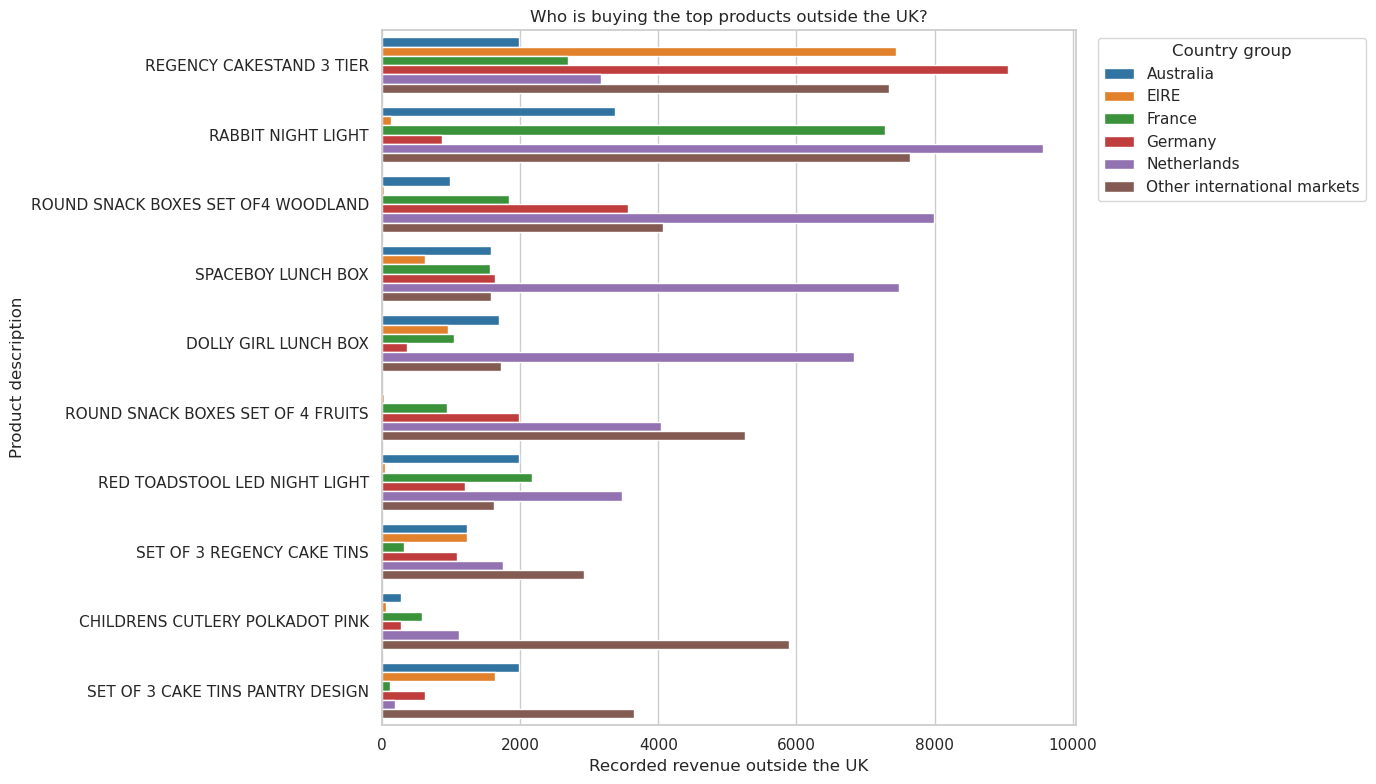

In [5]:
# I keep the top ten international products from the previous comparison.
top_product_descriptions = non_uk_product_revenue["Description"].tolist()

# I identify the five largest non-UK markets for the colour groups.
top_non_uk_countries = (
    df_non_uk.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

# I calculate product revenue by country for the selected products.
product_country_revenue = (
    df_non_uk[df_non_uk["Description"].isin(top_product_descriptions)]
    .groupby(["Description", "Country"])["Revenue"]
    .sum()
    .reset_index()
)

# I combine smaller markets so the hue legend remains readable.
product_country_revenue["CountryGroup"] = product_country_revenue["Country"].where(
    product_country_revenue["Country"].isin(top_non_uk_countries),
    "Other international markets",
)
product_country_revenue = (
    product_country_revenue
    .groupby(["Description", "CountryGroup"], as_index=False)["Revenue"]
    .sum()
)

display(product_country_revenue.sort_values("Revenue", ascending=False).head(20))

# I preserve the overall product ranking on the vertical axis.
product_order = non_uk_product_revenue["Description"].tolist()
plt.figure(figsize=(14, 8))
sns.barplot(
    data=product_country_revenue,
    x="Revenue",
    y="Description",
    hue="CountryGroup",
    order=product_order,
    palette="tab10",
)
plt.title("Who is buying the top products outside the UK?")
plt.xlabel("Recorded revenue outside the UK")
plt.ylabel("Product description")
plt.legend(title="Country group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_top_non_uk_products_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis — what the product-by-country view tells me

This chart turns my top-product list into a question about market mix. One caveat worth stating: `Other international markets` isn't one country, it's every smaller international market lumped together so the main colour groups stay readable.

The Netherlands is the pattern that keeps repeating. It's the largest named market for `RABBIT NIGHT LIGHT` (£9,568.48), `ROUND SNACK BOXES SET OF4 WOODLAND` (£7,991.40), `SPACEBOY LUNCH BOX` (£7,485.60), `DOLLY GIRL LUNCH BOX` (£6,828.60), and `RED TOADSTOOL LED NIGHT LIGHT` (£3,479.40). Five products, one country, consistently — that smells like a specific relationship rather than coincidence, and it's worth chasing.

It's not a universal pattern, though. Germany leads on `REGENCY CAKESTAND 3 TIER` (£9,061.95), with EIRE close behind on the same product (£7,442.85). The combined smaller-market group tops a few other products, but that's several countries stacked together, not one clear leader.

I'm treating this chart as a clue about where to dig next, not proof of a broad national preference. The Netherlands is the thread I want to pull at account level, and Question 2 is where that happens. For now it's a signal about where to look, not a verdict on Dutch buying habits — and revenue still isn't profit.

### Question 2 — which markets are busy and which are valuable?

I will compare countries on recorded revenue and on the number of distinct invoices, because volume and revenue answer different questions and I don't want to let one stand in for the other. The country table will show whether the Netherlands deserves the closer look suggested by the earlier product-by-country view.

In [6]:
# I group the clean table by country and keep both revenue and activity visible.
country_summary = (
    df_clean.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Rows=("InvoiceNo", "size"),
    )
    .sort_values("Revenue", ascending=False)
)

display(country_summary.head(10))
display(country_summary.loc[country_summary.index.isin(["United Kingdom", "Netherlands"])])

,Revenue,Transactions,Rows
Country,,,
United Kingdom,8438363.043,17852,478370
Netherlands,283889.340,93,2322
EIRE,266317.360,280,7733
Germany,205369.250,443,8642
France,183787.540,380,8060
Australia,137802.210,53,1119
Spain,55706.560,88,2417
Switzerland,53065.600,50,1927
Japan,37416.370,19,321


,Revenue,Transactions,Rows
Country,,,
United Kingdom,8438363.043,17852,478370
Netherlands,283889.340,93,2322


### Consequence — country scale and activity can now be separated

The country table shows that the UK dominates recorded revenue, while the Netherlands is second overall with 93 distinct invoices. That contrast makes transaction count an essential companion to country revenue, so I now plot the top countries before narrowing the view.

### Chart — top countries by recorded revenue

Seaborn handles the top-country revenue comparison. I've left the transaction-count comparison in the table rather than cramming it into the same chart — one chart, one job.

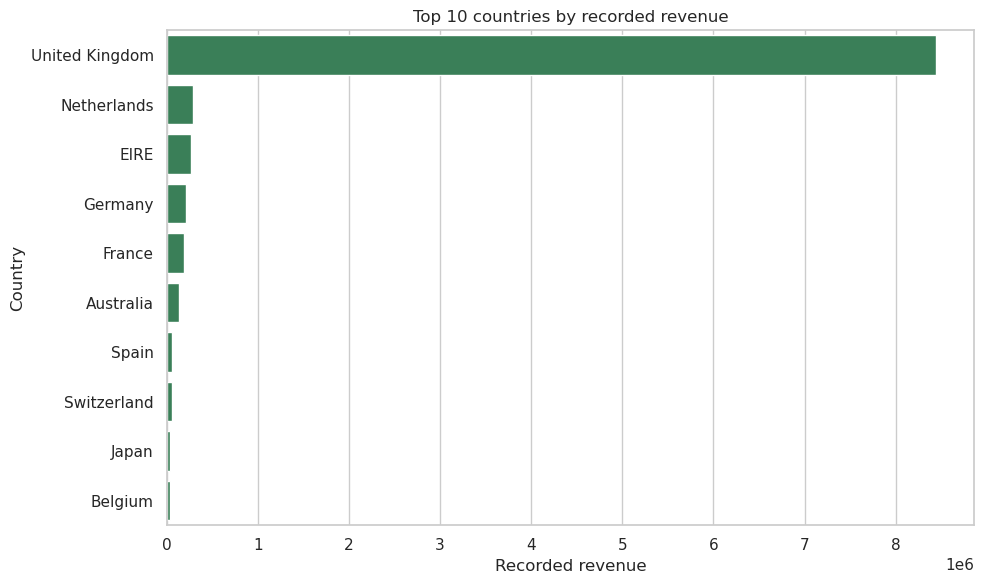

In [7]:
# I keep the country chart focused on revenue; transaction counts remain in the table.
top_countries = country_summary.head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x="Revenue", y="Country", color="seagreen")
plt.title("Top 10 countries by recorded revenue")
plt.xlabel("Recorded revenue")
plt.ylabel("Country")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_top_countries_by_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### Consequence — the UK scale masks international differences

The chart confirms that the UK bar dominates the shared axis. This is a display limitation, not an analytical reason to discard UK data, so I will now make a UK-excluded view so I can compare the international markets fairly without them being crushed by the dominance of the UK.

### Chart — international markets without the UK

The full country chart confirms the overall scale, but again the UK bar makes everything else nearly impossible to compare. So, same trick as before: a second view with the UK removed, so the Netherlands, EIRE, Germany, France, and the rest of the international field can actually be seen against each other.

,Country,Revenue
0,Netherlands,283889.34
1,EIRE,266317.36
2,Germany,205369.25
3,France,183787.54
4,Australia,137802.21
5,Spain,55706.56
6,Switzerland,53065.60
7,Japan,37416.37
8,Belgium,36927.34
9,Sweden,36828.83


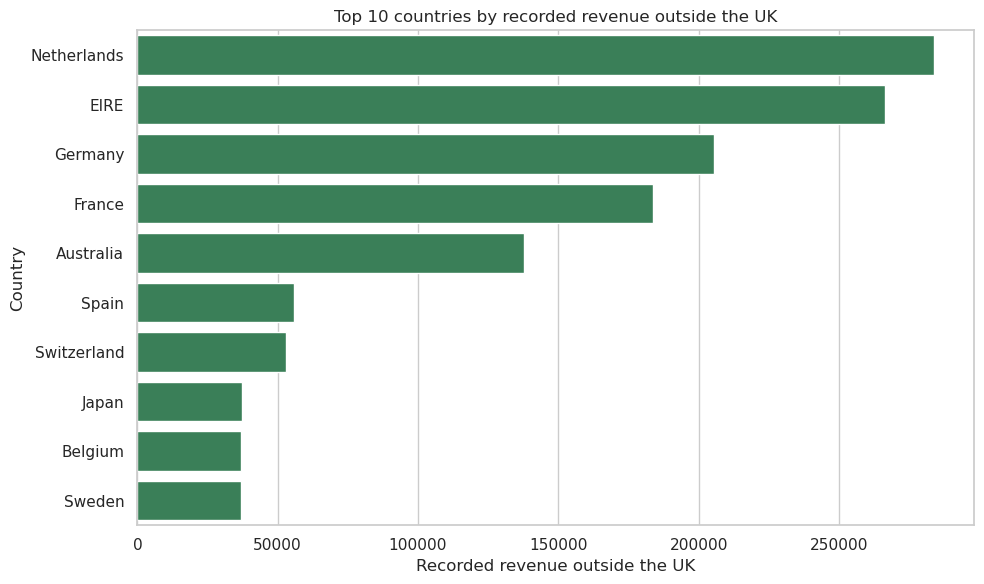

In [8]:
# I calculate the country comparison again without changing country_summary or df_clean.
non_uk_country_summary = (
    df_non_uk.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(non_uk_country_summary)

# I use Seaborn to show international country scale without the UK dominating the axis.
plt.figure(figsize=(10, 6))
sns.barplot(
    data=non_uk_country_summary,
    x="Revenue",
    y="Country",
    color="seagreen",
)
plt.title("Top 10 countries by recorded revenue outside the UK")
plt.xlabel("Recorded revenue outside the UK")
plt.ylabel("Country")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_top_non_uk_countries_by_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### Consequence — the Netherlands leads the non-UK revenue view

With the UK removed, the Netherlands is the highest recorded-revenue market in the chart and table, ahead of EIRE, Germany, and France. Its lead could reflect fewer, larger invoices rather than broader activity, so I test revenue per transaction next.

### Question 2A — is Netherlands valuable per transaction?

The country table puts Netherlands second in recorded revenue, but with far fewer transactions than EIRE, Germany, France, or the UK. So I calculate revenue per distinct invoice, to compare market value sale-by-sale rather than only at the scale of a whole country.

Quick note: I use `EIRE` because that's how Ireland is labelled in this dataset, not a choice of mine. And revenue per transaction is built from recorded revenue, so what it measures is the size of a sale — not what was actually earned on it.

In [9]:
# I select the markets needed to investigate the Netherlands result against useful comparators.
comparison_countries = [
    "Netherlands", "EIRE", "Germany", "France", "United Kingdom"
]

market_comparison = country_summary.loc[comparison_countries].copy()

# I calculate the average recorded revenue attached to one distinct invoice.
market_comparison["RevenuePerTransaction"] = (
    market_comparison["Revenue"] / market_comparison["Transactions"]
)

# I keep the exact measures visible before I interpret the comparison.
display(market_comparison[
    ["Revenue", "Transactions", "RevenuePerTransaction", "Rows"]
].sort_values("RevenuePerTransaction", ascending=False))

,Revenue,Transactions,RevenuePerTransaction,Rows
Country,,,,
Netherlands,283889.340,93,3052.573548,2322
EIRE,266317.360,280,951.133429,7733
France,183787.540,380,483.651421,8060
United Kingdom,8438363.043,17852,472.684464,478370
Germany,205369.250,443,463.587472,8642


### Consequence — market size and transaction count tell different stories

The selected-market table puts the Netherlands at £283,889 across 93 distinct invoices, versus EIRE’s £266,317 across 280. Revenue per transaction therefore becomes the next useful comparison, not another raw-revenue ranking.

### Chart — revenue per transaction

I plot revenue per transaction across the selected markets. This is the direct test of whether the Netherlands result comes down to unusually high value per recorded sale.

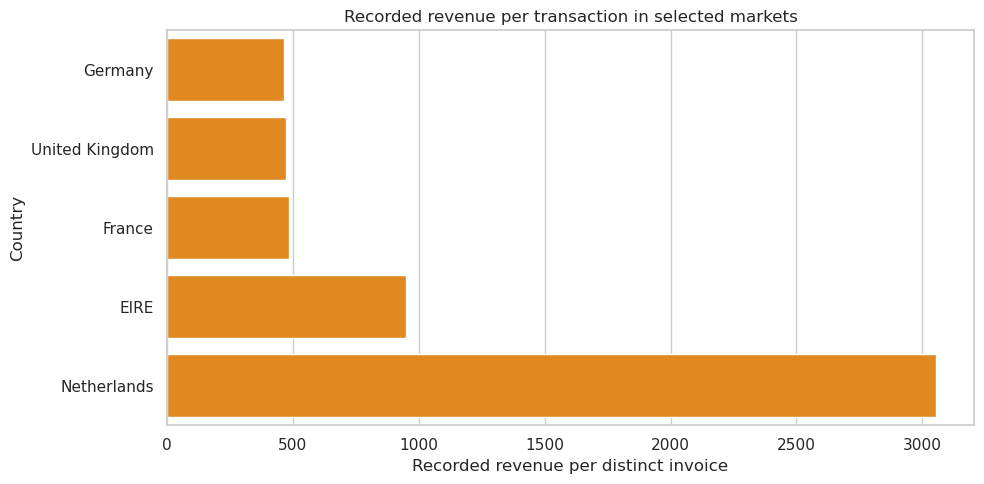

In [10]:
# I sort the bars so the highest recorded revenue per transaction is easiest to see.
market_plot = (
    market_comparison
    .reset_index()
    .sort_values("RevenuePerTransaction")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=market_plot,
    x="RevenuePerTransaction",
    y="Country",
    color="darkorange",
)
plt.title("Recorded revenue per transaction in selected markets")
plt.xlabel("Recorded revenue per distinct invoice")
plt.ylabel("Country")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_revenue_per_transaction_selected_markets.png", dpi=150, bbox_inches="tight")
plt.show()

### Consequence — the Netherlands lead is much larger per invoice

The bars show that the Netherlands has the highest recorded revenue per distinct invoice, well above the comparison markets. Averages can be driven by a few unusually large invoices, so I now inspect the distribution using median, quartile, and P90 values.

### Chart — transaction-value distribution

I am told averages are easy to fool — a handful of large invoices can drag one upward and make a market look bigger than it is. So instead I compare the median, upper quartile, and 90th percentile of transaction revenue, and look at the distribution itself. That's what actually tells me whether the Netherlands pattern is broad, or resting on a few high-value sales.

,Median,Mean,UpperQuartile,P90
Country,,,,
Netherlands,814.620,3052.573548,4311.4800,9936.128
EIRE,624.710,951.133429,958.7100,1591.335
Germany,318.850,463.587472,594.2250,929.176
France,344.570,483.651421,564.6250,956.912
United Kingdom,299.435,472.684464,459.9675,848.969


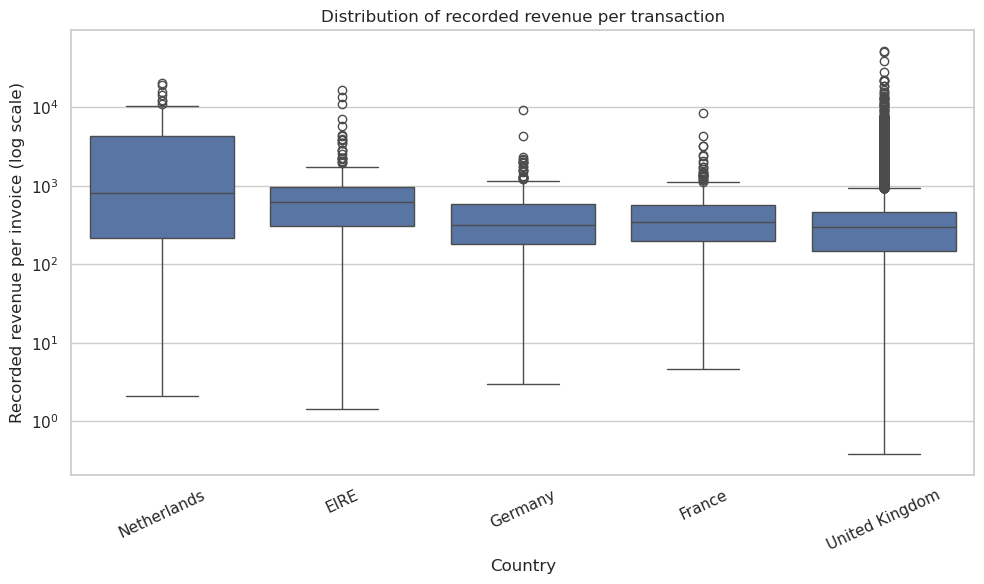

In [11]:
# I calculate one recorded-revenue value for each country and invoice.
transaction_values = (
    df_clean[df_clean["Country"].isin(comparison_countries)]
    .groupby(["Country", "InvoiceNo"], as_index=False)
    .agg(TransactionRevenue=("Revenue", "sum"))
)

# I calculate comparable summary statistics before plotting the distributions.
transaction_summary = (
    transaction_values.groupby("Country")["TransactionRevenue"]
    .agg(Median="median", Mean="mean")
    .reindex(comparison_countries)
)
transaction_summary["UpperQuartile"] = (
    transaction_values.groupby("Country")["TransactionRevenue"]
    .quantile(0.75)
    .reindex(comparison_countries)
)
transaction_summary["P90"] = (
    transaction_values.groupby("Country")["TransactionRevenue"]
    .quantile(0.90)
    .reindex(comparison_countries)
)

display(transaction_summary)

# I use a logarithmic y-axis because transaction values span a wide range.
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=transaction_values,
    x="Country",
    y="TransactionRevenue",
    order=comparison_countries,
)
plt.yscale("log")
plt.title("Distribution of recorded revenue per transaction")
plt.xlabel("Country")
plt.ylabel("Recorded revenue per invoice (log scale)")
plt.xticks(rotation=25)
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_transaction_revenue_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Consequence — the distribution confirms a high-value tail

The summary and boxplot show that the Netherlands has the highest median, upper quartile, and 90th-percentile transaction values among the selected markets, while its mean is also elevated. The next question is whether this pattern is spread across Dutch customers or concentrated in one relationship.

### Chart — Netherlands customer concentration

High-ticket transactions are interesting commercially — product mix and margin might deserve a closer look. But interesting isn't the same as profitable, and margin isn't a field I have. Before I go calling the Netherlands a broad market opportunity, I want to know one thing: is that revenue spread across a real customer base, or is it resting on a single relationship?

In [12]:
# I summarise Netherlands revenue and activity by customer.
netherlands_customer_summary = (
    df_clean[df_clean["Country"] == "Netherlands"]
    .groupby("CustomerID")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("InvoiceNo", "nunique"),
    )
    .sort_values("Revenue", ascending=False)
)

# I calculate each customer's share of Netherlands recorded revenue.
netherlands_customer_summary["RevenueShare"] = (
    netherlands_customer_summary["Revenue"]
    / netherlands_customer_summary["Revenue"].sum()
)

display(netherlands_customer_summary)

,Revenue,Transactions,RevenueShare
CustomerID,,,
14646,279138.02,72,0.983263
12759,1411.44,3,0.004972
12775,1281.04,5,0.004512
12778,693.23,6,0.002442
12787,418.66,3,0.001475
12802,397.58,1,0.001400
12790,294.92,1,0.001039
12791,177.60,1,0.000626
12789,76.85,1,0.000271


### Consequence — the Dutch revenue is concentrated in a small customer table

The customer-level table shows how many identified customers and transactions sit behind Netherlands recorded revenue. That gives me the concentration signal, but it does not yet show whether the leading customer is a one-off buyer or a sustained relationship. I now inspect the leading customer’s products and timing.

### Question 2B — is 14646 itself another whale?  A placeholder, not a real customer?

On this evidence it looks like I may have lost one whale, only to stumble into another. This makes me cautious, so before I build a Netherlands opportunity on top of one customer ID, I need to rule out the same problem this project already found once. Ghost whales. `15287` looked like a normal ID yet turned out to be a catchall. So I am going to check whether `14646` shows the same signature: spread across many countries, a row count that dwarfs every other customer, and order data that doesn't look like real repeat business.  No more wild goose chases for this student.

In [13]:
# I test three things that distinguish a real high-volume customer from a placeholder
# like 15287: whether the ID is confined to one country, whether its row count is in
# line with other real customers rather than dwarfing them, and whether its invoices
# look like genuine repeat orders rather than an undifferentiated dump.

customer_country_spread = df_clean[df_clean["CustomerID"] == 14646]["Country"].value_counts()

rows_per_customer = df_clean.groupby("CustomerID").size().sort_values(ascending=False)
customer_14646_rank = rows_per_customer.index.get_loc(14646) + 1
customer_14646_rows = rows_per_customer.loc[14646]
placeholder_rows = rows_per_customer.loc[15287]

invoice_line_counts = (
    df_clean[df_clean["CustomerID"] == 14646]
    .groupby("InvoiceNo")
    .size()
)

print("Countries 14646 appears under:")
display(customer_country_spread)

print(f"\nRow-count rank of 14646 among {len(rows_per_customer)} customers: {customer_14646_rank}")
print(f"14646 total rows: {customer_14646_rows}")
print(f"For comparison, the known placeholder 15287 has {placeholder_rows} rows.")

print("\nInvoice line-count distribution for 14646 (lines per order):")
display(invoice_line_counts.describe())

Countries 14646 appears under:


Country
Netherlands    2060
Name: count, dtype: int64[pyarrow]


Row-count rank of 14646 among 4333 customers: 8
14646 total rows: 2060
For comparison, the known placeholder 15287 has 131407 rows.

Invoice line-count distribution for 14646 (lines per order):


count     72.000000
mean      28.611111
std       31.992321
min        1.000000
25%        5.500000
50%       14.000000
75%       45.500000
max      125.000000
dtype: float64

### Consequence — 14646 does not match the 'Ghost Whale' placeholder signature

The check shows that `14646` appears under one country only, the Netherlands, and carries 2,060 rows. It ranks eighth among 4,333 customer IDs, while the known placeholder `15287` carries 131,407 rows. Its 72 invoices also have a varied line-count distribution rather than one undifferentiated dump. On this evidence, `14646` is a high-volume Netherlands relationship worth investigating further, not another placeholder bucket.  No whales sighted.

### Next step — inspect the leading customer’s buying pattern

The customer summary tells me where the revenue sits. I now test whether the leading customer appears across months, products, and order quantities before treating the concentration as commercially meaningful.

In [14]:
customer_14646 = df_clean[
    (df_clean["Country"] == "Netherlands")
    & (df_clean["CustomerID"] == 14646)
].copy()
customer_14646_detail = pd.DataFrame({
    "Transactions": [customer_14646["InvoiceNo"].nunique()],
    "Months": [customer_14646["Month"].nunique()],
    "DistinctProducts": [customer_14646["StockCode"].nunique()],
    "MedianUnitsPerLine": [customer_14646["Quantity"].median()],
})
display(customer_14646_detail)

customer_14646_monthly_orders = (
    customer_14646.groupby("Month")["InvoiceNo"]
    .nunique()
    .reset_index(name="Transactions")
)
display(customer_14646_monthly_orders)

,Transactions,Months,DistinctProducts,MedianUnitsPerLine
0,72,13,699,72.0


,Month,Transactions
0,2010-12,2
1,2011-01,4
2,2011-02,4
3,2011-03,4
4,2011-04,3
5,2011-05,8
6,2011-06,7
7,2011-07,1
8,2011-08,7
9,2011-09,6


### Consequence — the concentration has a measurable buying pattern

The detail tables show the leading customer’s distinct products, active months, order count, and monthly order pattern. That lets me judge the shape of the relationship rather than relying on one percentage. I now make the customer concentration visible in a chart.

### Next step — visualise the customer concentration

The supporting detail is now visible in tables. A categorical bar chart will show how the leading customer compares with the rest of the Dutch customer population.

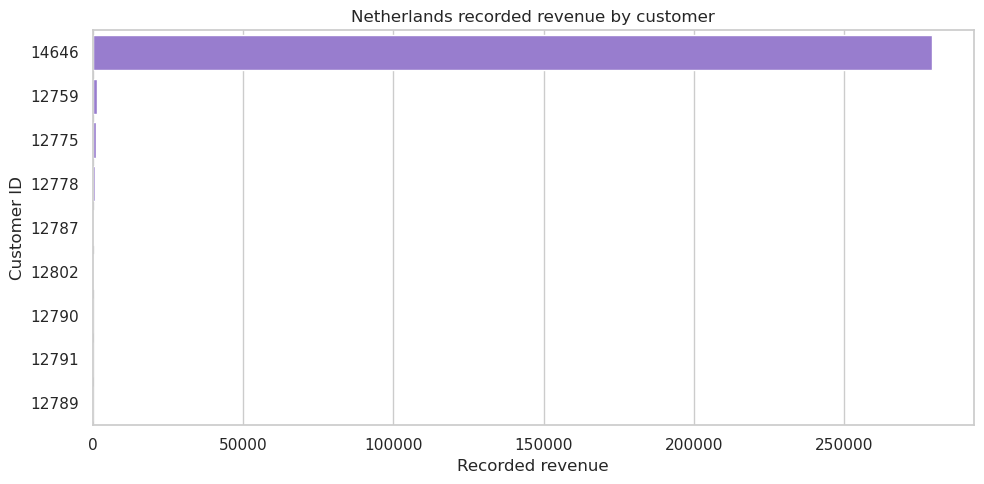

In [15]:
# I show the small customer population so concentration is visible rather than hidden in an average.
customer_plot = netherlands_customer_summary.reset_index()

# I treat customer IDs as category labels so Seaborn uses them on the y-axis.
customer_plot["CustomerID"] = customer_plot["CustomerID"].astype("string")

plt.figure(figsize=(10, 5))
sns.barplot(data=customer_plot, x="Revenue", y="CustomerID", color="mediumpurple")
plt.title("Netherlands recorded revenue by customer")
plt.xlabel("Recorded revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_netherlands_customer_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis — the Netherlands opportunity

The signature didn't match, so this is a real relationship, not a second placeholder — and on that evidence, the Netherlands is a credible relationship-level opportunity. It has the second-highest recorded revenue, but only 93 distinct transactions. Its recorded revenue per transaction is much higher than the selected comparison markets. That supports a closer look at product mix, order size, customer type, fulfilment cost, and margin.

The concentration check finds the opportunity rather than dissolving it. Customer `14646` contributes 98.3% of Netherlands recorded revenue. The detail table shows 72 separate orders spread across all thirteen months, 699 distinct products, and a median of 72 units per line. That pattern looks more like business restocking than ordinary household buying.

The dataset has no customer-type field, so I cannot call `14646` a reseller as a proven fact. The repeated, high-volume pattern is consistent with resale or another business purchasing role, but the data cannot tell me which.

The timing settles it. `14646`'s order count climbs into the autumn, with 11 orders in October and 12 in November. Earlier months vary — 4 in March, 3 in April, and 8 in May — so I describe the evidence as an increase into autumn rather than calling all spring months uniformly low. Their restocking follows the same Christmas curve as the UK retail market. Something downstream of them is pulling this product through, and that something is Dutch end-market demand.

One thing I checked deliberately: the whale's placeholder identifier `15287` does not appear anywhere in the Netherlands customer table above. Every Dutch customer here is a real, identified one, so this finding is untouched by the attribution problem I found during the ETL work.

So my recommendation to the Commercial Director is that the Netherlands is a live market opportunity, and there are two routes into it. The first is to deepen the relationship with `14646` and treat them as what they functionally already are — a distribution agent in that market, worth better terms, earlier sight of new lines and stock priority ahead of the autumn ramp. The second is to look at going more directly at Dutch demand, because the evidence says the demand exists and one intermediary is currently capturing all of it.

What I am not claiming is margin. Revenue per transaction measures the size of a sale, not what was earned on it, and a reseller relationship of this size will carry discount terms I cannot see. The next evidence I would want is product-level margin, the terms on this account, and whether any other Dutch customers show the same buying shape or whether `14646` genuinely is the whole market.

### Question 3 — how does recorded revenue change by month?

I group the clean table by month, looking for peaks, quiet stretches, and the limits of what this kind of comparison can actually show. Whatever shape turns up here describes what was recorded — the reason behind a rise or a fall is a question no revenue column can answer on its own.

,Month,Revenue
0,2010-12,772146.850
1,2011-01,591151.480
2,2011-02,507596.320
3,2011-03,687125.080
4,2011-04,513876.361
5,2011-05,739766.320
6,2011-06,735463.510
7,2011-07,686754.851
8,2011-08,719669.380
9,2011-09,1023782.111


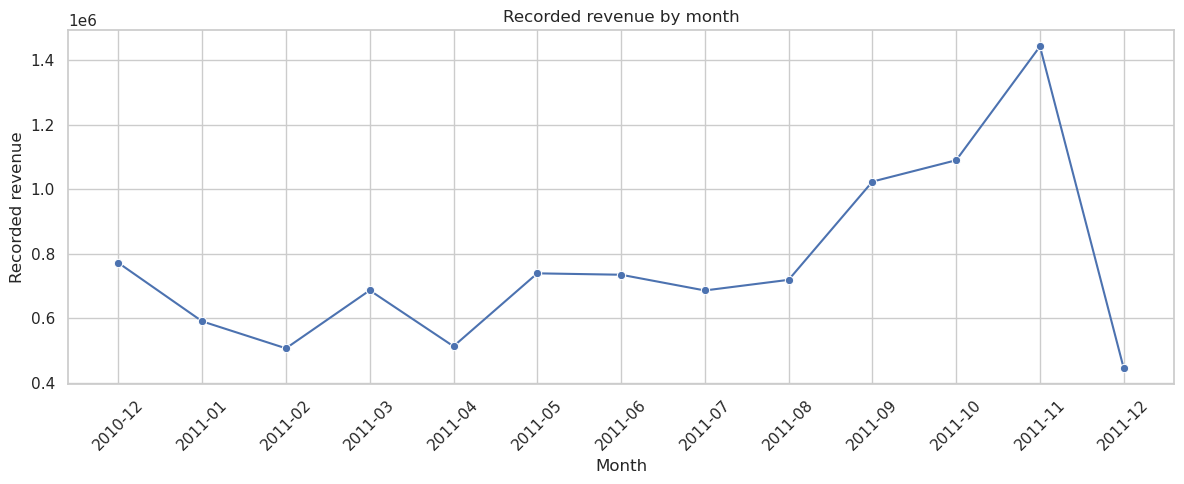

In [16]:
# I group recorded revenue by month to reveal the shape of the observed time period.
monthly_revenue = (
    df_clean.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

display(monthly_revenue)

# I use Seaborn for the monthly trend after displaying the table of values.
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x="Month", y="Revenue", marker="o")
plt.title("Recorded revenue by month")
plt.xlabel("Month")
plt.ylabel("Recorded revenue")
plt.xticks(rotation=45)
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis — what the monthly overview tells me

The shape of the year is more than one trough. February 2011 is the lowest complete month in the observed year; March rebounds, April dips again, and May returns to a higher level. Revenue then stays broadly steady through August before a clear run upward from September into November — the highest complete month in the comparable period. I'm not reading the December 2011 drop as a New Year decline, though, because the dataset stops on 9 December 2011. December simply never finished.

### Question 3A — is the movement driven by order volume or order value?

I break monthly recorded revenue down into invoices, quantity, identified active customers, and revenue per invoice — enough to tell a broad rise in demand apart from a handful of unusually large orders skewing the total.

In [17]:
# I calculate the main monthly drivers behind recorded revenue.
monthly_metrics = (
    df_clean.groupby("Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Invoices=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum"),
    )
    .reset_index()
    .sort_values("Month")
)

# The placeholder 15287 would collapse every unattributed row into one customer,
# so I set those rows aside before counting customers.
df_identified = df_clean[df_clean["CustomerID"] != 15287].copy()

# I count the identified customers active in each month.
monthly_identified = df_identified.groupby("Month")["CustomerID"].nunique()

# I look each month up in that count and attach it to the table.
monthly_metrics["IdentifiedActiveCustomers"] = (
    monthly_metrics["Month"].map(monthly_identified)
)

# I calculate the recorded revenue attached to one distinct invoice.
monthly_metrics["RevenuePerInvoice"] = (
    monthly_metrics["Revenue"] / monthly_metrics["Invoices"]
)

display(monthly_metrics)

,Month,Revenue,Invoices,Quantity,IdentifiedActiveCustomers,RevenuePerInvoice
0,2010-12,772146.850,1546,356005,884,499.448157
1,2011-01,591151.480,1077,311743,738,548.887168
2,2011-02,507596.320,1091,282581,756,465.257855
3,2011-03,687125.080,1436,375014,972,478.499359
4,2011-04,513876.361,1231,307163,853,417.446272
5,2011-05,739766.320,1664,394581,1054,444.571106
6,2011-06,735463.510,1518,386088,988,484.495066
7,2011-07,686754.851,1449,398276,945,473.950898
8,2011-08,719669.380,1338,418301,933,537.869492
9,2011-09,1023782.111,1815,567537,1257,564.067279


### Consequence — the monthly driver table is ready for comparison

The table now places recorded revenue beside distinct invoices, quantity, identified active customers, and revenue per invoice. Those measures let me separate broad order activity from unusually large invoices. I now turn the two clearest drivers into aligned charts.

### Next step — visualise revenue and invoice activity

The monthly values are established before plotting. I use separate panels because revenue and invoice counts have different units and need separate scales.

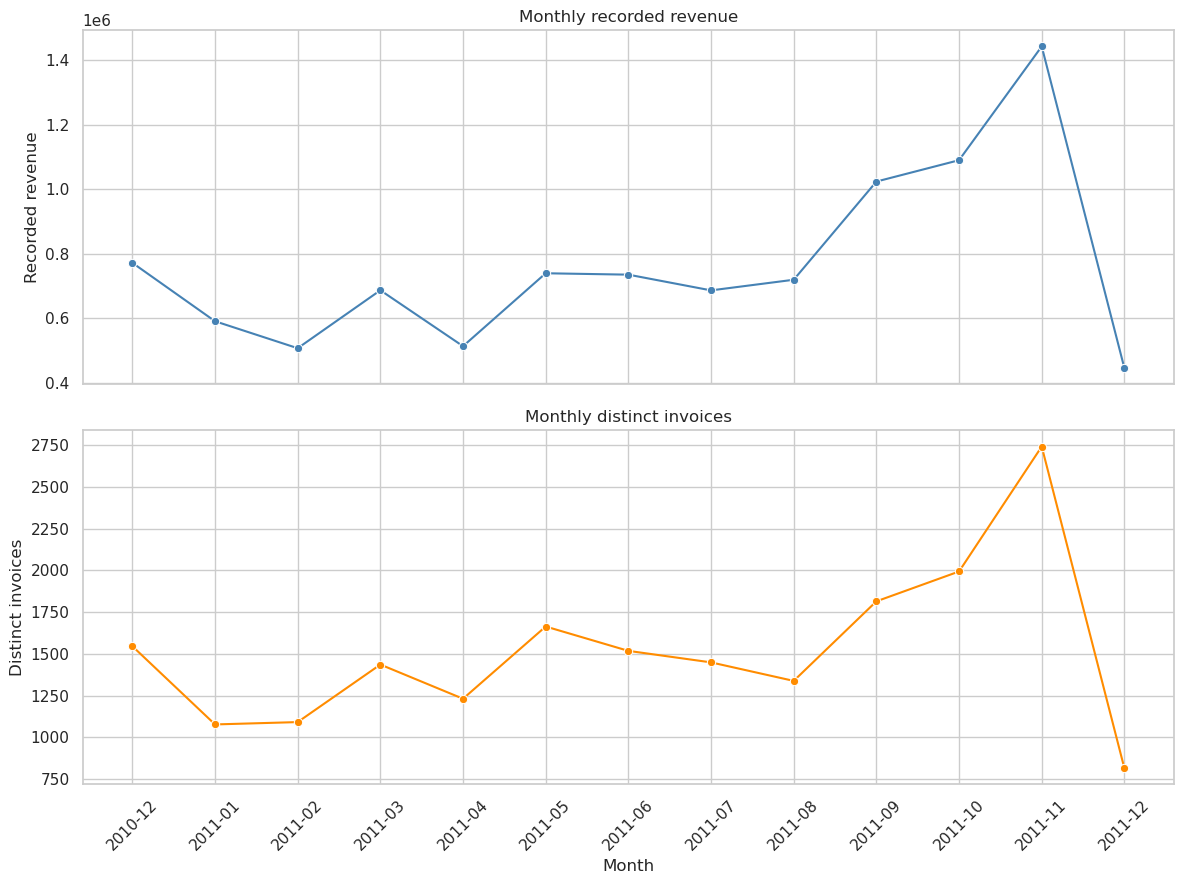

In [18]:
# I use separate Seaborn panels because revenue and invoice counts have different units.
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=monthly_metrics,
    x="Month",
    y="Revenue",
    marker="o",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Monthly recorded revenue")
axes[0].set_xlabel("")
axes[0].set_ylabel("Recorded revenue")

sns.lineplot(
    data=monthly_metrics,
    x="Month",
    y="Invoices",
    marker="o",
    color="darkorange",
    ax=axes[1],
)
axes[1].set_title("Monthly distinct invoices")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Distinct invoices")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_monthly_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis — the peak is built on order volume

The November increase is mainly volume-led. Against October, November has more distinct invoices, more identified active customers, and more quantity moving — while revenue per invoice actually dips slightly. That's a broad lift in order activity, not a jump in what people spend per order, and it's directly useful for capacity, stock, and staffing decisions. Why it's happening is a different question, and this data doesn't carry that answer.

### Question 3B — when does the Christmas ramp begin?

I examine weekly revenue and invoice counts across 2011 up to the November peak, leaving December out because the data there is incomplete. The aim is to give the Commercial Director genuinely useful lead time for stock and operational planning — not just confirm what everyone already suspects about Christmas.

In [19]:
# I create weekly measures so the timing of the autumn increase is visible.
weekly_metrics = (
    df_clean.assign(
        WeekStart=df_clean["InvoiceDate"].dt.to_period("W").dt.start_time
    )
    .groupby("WeekStart")
    .agg(
        Revenue=("Revenue", "sum"),
        Invoices=("InvoiceNo", "nunique"),
    )
    .reset_index()
)

# I reuse the identified-customer table created for the monthly view.
weekly_identified = (
    df_identified.assign(
        WeekStart=df_identified["InvoiceDate"].dt.to_period("W").dt.start_time
    )
    .groupby("WeekStart")["CustomerID"]
    .nunique()
)

# I look each week up in that count and attach it to the table.
weekly_metrics["IdentifiedActiveCustomers"] = (
    weekly_metrics["WeekStart"].map(weekly_identified)
)

# I run the window from January so the ramp has to reveal itself against the whole
# year rather than against a start date I picked. It ends on 28 November because
# December 2011 is only part-traded.
weekly_ramp = weekly_metrics[
    (weekly_metrics["WeekStart"] >= "2011-01-01")
    & (weekly_metrics["WeekStart"] <= "2011-11-28")
].copy()

display(weekly_ramp)

,WeekStart,Revenue,Invoices,IdentifiedActiveCustomers
4,2011-01-03,128729.740,241,207
5,2011-01-10,187180.000,257,211
6,2011-01-17,132122.160,228,184
7,2011-01-24,120675.380,290,243
8,2011-01-31,121309.810,294,245
9,2011-02-07,103415.840,220,182
10,2011-02-14,140305.110,294,236
11,2011-02-21,145234.070,289,245
12,2011-02-28,127546.650,283,242
13,2011-03-07,129019.740,290,227


### Consequence — the complete weekly ramp window is defined

The weekly table covers January through 28 November, so the autumn change is compared with the full preceding year rather than a chosen starting slice. I now plot revenue and invoice activity on separate panels.

### Next step — visualise the weekly ramp

The table establishes the values and the comparable window. Separate panels keep revenue and invoice counts readable while preserving their shared timeline.

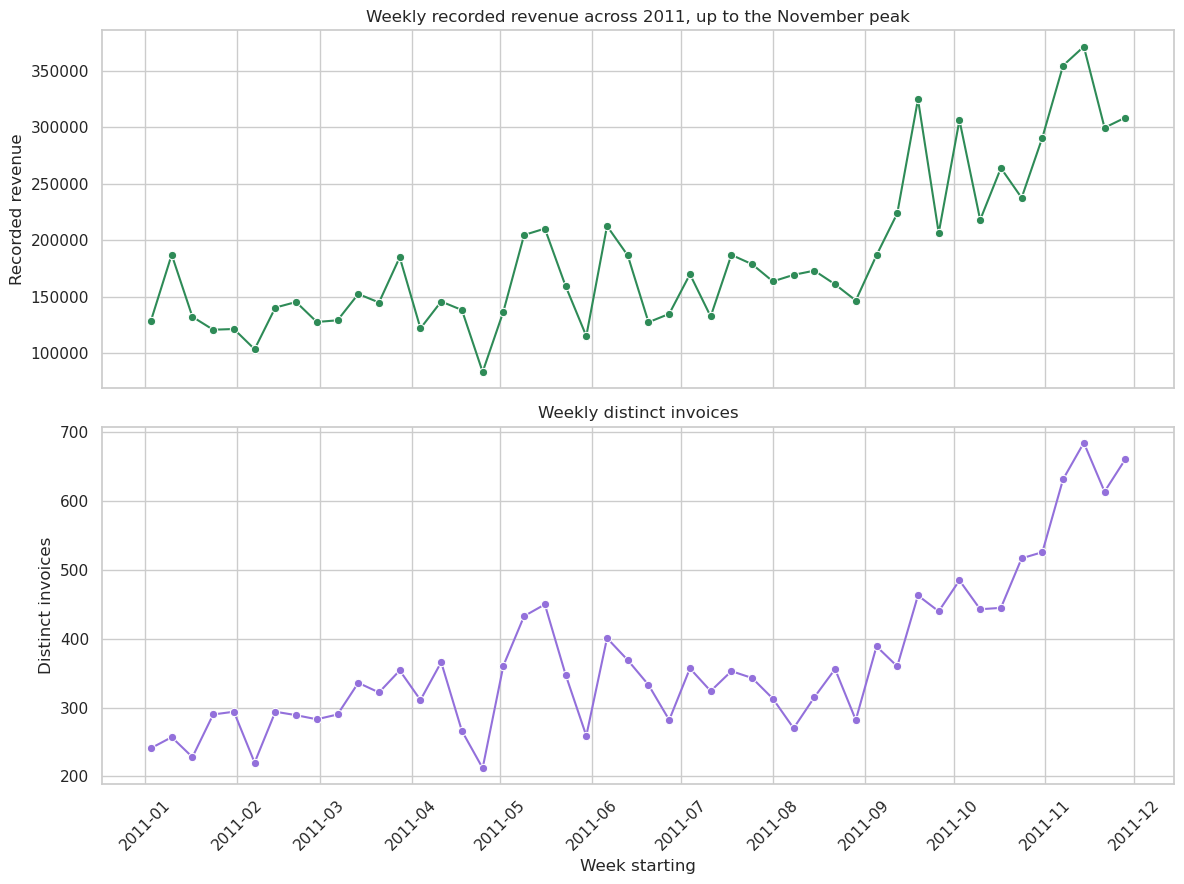

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=weekly_ramp,
    x="WeekStart",
    y="Revenue",
    marker="o",
    color="seagreen",
    ax=axes[0],
)
axes[0].set_title("Weekly recorded revenue across 2011, up to the November peak")
axes[0].set_xlabel("")
axes[0].set_ylabel("Recorded revenue")

sns.lineplot(
    data=weekly_ramp,
    x="WeekStart",
    y="Invoices",
    marker="o",
    color="mediumpurple",
    ax=axes[1],
)
axes[1].set_title("Weekly distinct invoices")
axes[1].set_xlabel("Week starting")
axes[1].set_ylabel("Distinct invoices")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_weekly_christmas_ramp.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis — the ramp starts in September

Widening the window to the whole of 2011 answers this properly. From January through August, weekly revenue is noisy, ranging from roughly £83,000 to £213,000, but it shows no sustained upward trend. The September-to-November averages then step up to about £235,000, £263,000, and £334,000 respectively.

So the ramp starts in September, and I can say that with some confidence, because the eight flat months sitting in front of it are right there in the same chart. Plot only from August onwards and September looks like a rise from an arbitrary starting line — there'd be no way to tell a real breakout from a chart that just happened to start in the wrong place.

For the Commercial Director, the practical read is about lead time. The decisions that support November — stock, staffing, supplier commitments — have to be made in late summer. By the time the peak shows up in the weekly numbers, it's already too late to prepare for it.

### Question 3C — which products create the seasonal lift?

I compare product revenue across Winter, Spring, Summer, Autumn, and the November peak — held out on its own, since that's the period I'm actually trying to understand. A heatmap suits this well: it shows the persistent products and the concentrated ones in the same picture.

On what makes the cut: the data ends early in December 2011, so that partial month is excluded. Everything else stays in, including December 2010, which is part of the observed trading period.

In [21]:
# December 2011 traded for only 8 days before the data stops, against 24 in a normal
# month, so it comes out. Every other month is a full trading month and stays in.
seasonal_data = df_clean[df_clean["Month"] != "2011-12"].copy()

# Four seasons of three months each, so no season is longer than another.
seasonal_data["Season"] = seasonal_data["InvoiceDate"].dt.month.map(
    {
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Autumn", 10: "Autumn", 11: "Autumn",
    }
)

# I keep stock code with description so similar descriptions stay distinguishable.
seasonal_data["Product"] = (
    seasonal_data["StockCode"] + " \u2014 " + seasonal_data["Description"]
)

# I count how many months each season actually contains so I can average per month.
months_in_season = seasonal_data.groupby("Season")["Month"].nunique()
print("Months contributing to each season:")
display(months_in_season)

Months contributing to each season:


Season
Autumn    3
Spring    3
Summer    3
Winter    3
Name: Month, dtype: int64

### Consequence — the seasonal comparison is standardised

The partial December 2011 month is excluded, seasons are assigned evenly, and product labels retain both stock code and description. The month counts confirm how many complete months contribute to each season. I now aggregate those prepared rows into a comparable product-by-period table.

### Next step — build the seasonal product table

The seasonal rows are now labelled and their coverage is known. I calculate average monthly recorded revenue for the top products and keep November as a separate peak-period column.

In [22]:
season_product_revenue = (
    seasonal_data.groupby(["Product", "Season"])["Revenue"].sum().reset_index()
)

top_season_products = (
    season_product_revenue.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_product_matrix = (
    season_product_revenue[season_product_revenue["Product"].isin(top_season_products)]
    .pivot_table(
        index="Product", columns="Season", values="Revenue",
        aggfunc="sum", fill_value=0,
    )
    .reindex(index=top_season_products, columns=season_order, fill_value=0)
)

# Totals are not comparable across seasons of different length, so I convert each
# season to an average month. Now every column means the same thing.
for season in season_order:
    season_product_matrix[season] = (
        season_product_matrix[season] / months_in_season[season]
    )

# November is one month, so its total is already a monthly figure. I add it as a
# spotlight on the peak rather than as a fifth season; it is part of Autumn too.
november_revenue = (
    seasonal_data[seasonal_data["InvoiceDate"].dt.month == 11]
    .groupby("Product")["Revenue"]
    .sum()
)
season_product_matrix["November alone"] = (
    season_product_matrix.index.map(november_revenue).fillna(0)
)
# Matplotlib needs ordinary numeric columns for the heatmap.
season_product_matrix = season_product_matrix.astype(float)

display(season_product_matrix.round(0))

Season,Winter,Spring,Summer,Autumn,November alone
Product,,,,,
22423 — REGENCY CAKESTAND 3 TIER,17160.0,15055.0,11280.0,12123.0,13494.0
85123A — WHITE HANGING HEART T-LIGHT HOLDER,9835.0,8932.0,6266.0,8609.0,14131.0
47566 — PARTY BUNTING,2613.0,13007.0,12269.0,4947.0,4741.0
85099B — JUMBO BAG RED RETROSPOT,4840.0,7373.0,8041.0,9958.0,11460.0
23084 — RABBIT NIGHT LIGHT,0.0,759.0,2510.0,15808.0,34466.0
22086 — PAPER CHAIN KIT 50'S CHRISTMAS,3124.0,113.0,998.0,14822.0,28956.0
84879 — ASSORTED COLOUR BIRD ORNAMENT,3196.0,4507.0,5204.0,6007.0,8382.0
79321 — CHILLI LIGHTS,5569.0,1914.0,2946.0,6614.0,11486.0
23298 — SPOTTY BUNTING,0.0,2562.0,7127.0,4227.0,4454.0


### Consequence — the product-by-period values are visible

The table now shows the same unit—average monthly recorded revenue—for each full season, with November displayed separately as the peak spotlight. I now use a heatmap to compare persistence and concentration at a glance.

### Next step — visualise seasonal product mix

The matrix has established the values before the chart. The heatmap will reveal which products are steady across periods and which rise mainly into November.

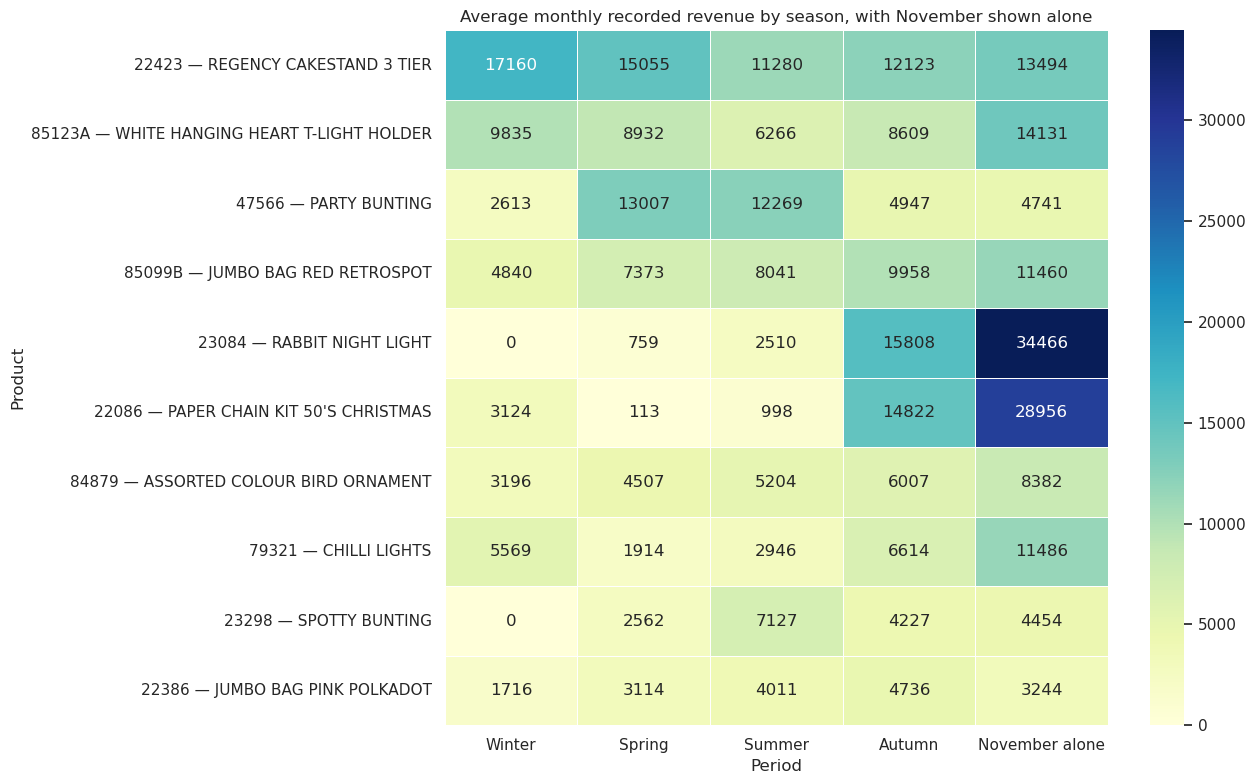

In [23]:
# I use a Seaborn heatmap to show persistent and concentrated product demand.
plt.figure(figsize=(13, 8))
sns.heatmap(
    season_product_matrix, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5,
)
plt.title("Average monthly recorded revenue by season, with November shown alone")
plt.xlabel("Period")
plt.ylabel("Product")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_seasonal_product_mix.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis — evergreen products and seasonal products

The heatmap splits evergreen products from seasonal ones cleanly. Regency Cake Stand 3 Tier and White Hanging Heart T-Light Holder hold up across several periods, Party Bunting strengthens through Spring and Summer, and Paper Chain Kit 50's Christmas and Rabbit Night Light both rise sharply into November — Jumbo Bag Red Retrospot right alongside them in Autumn and November. That's evidence enough to plan different stock and campaign calendars by product, rather than treating everything as a year-round seller.

### Question 3D — is the peak domestic or international?

I compare the UK against everywhere else using monthly revenue *share*, not raw revenue — the UK is so much larger that a raw-revenue chart would flatten the international pattern into invisibility.

,Month,MarketGroup,Revenue,RevenueShare
0,2011-03,Outside UK,118379.880,0.172283
1,2011-03,United Kingdom,568745.200,0.827717
2,2011-04,Outside UK,50085.970,0.097467
3,2011-04,United Kingdom,463790.391,0.902533
4,2011-05,Outside UK,121745.620,0.164573
5,2011-05,United Kingdom,618020.700,0.835427
6,2011-06,Outside UK,132241.820,0.179807
7,2011-06,United Kingdom,603221.690,0.820193
8,2011-07,Outside UK,110911.780,0.161501
9,2011-07,United Kingdom,575843.071,0.838499


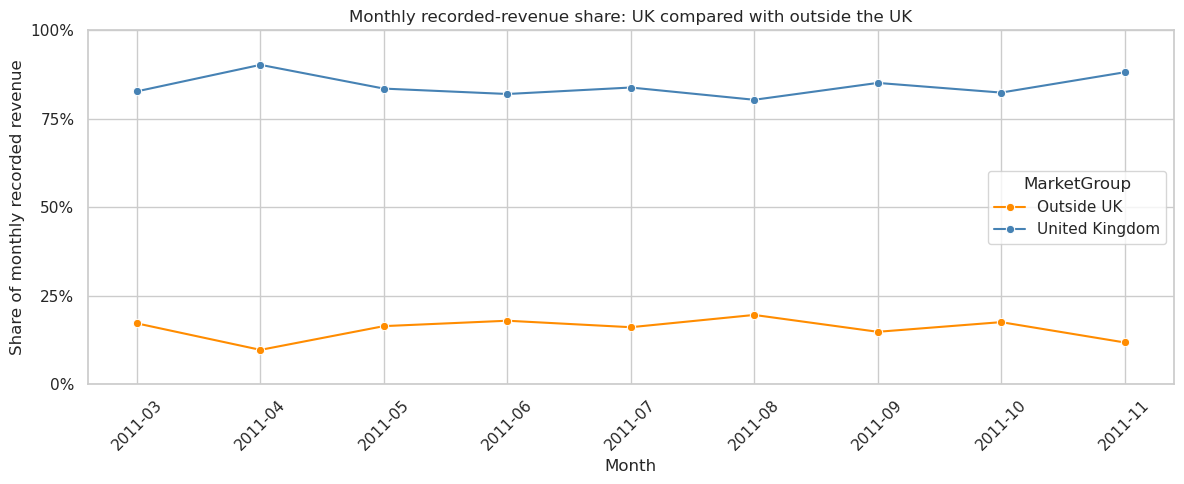

In [24]:
# I compare market groups over the complete comparable period from March to November 2011.
comparable_market_data = df_clean[
    (df_clean["InvoiceDate"] >= "2011-03-01")
    & (df_clean["InvoiceDate"] < "2011-12-01")
].copy()

comparable_market_data["MarketGroup"] = comparable_market_data["Country"].where(
    comparable_market_data["Country"] == "United Kingdom",
    "Outside UK",
)

market_mix = (
    comparable_market_data.groupby(["Month", "MarketGroup"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

# I calculate each market group's share of its month's recorded revenue.
market_mix["RevenueShare"] = (
    market_mix["Revenue"]
    / market_mix.groupby("Month")["Revenue"].transform("sum")
)

display(market_mix)

# I use share rather than raw revenue so the international line remains visible.
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=market_mix,
    x="Month",
    y="RevenueShare",
    hue="MarketGroup",
    marker="o",
    palette={"United Kingdom": "steelblue", "Outside UK": "darkorange"},
)
plt.title("Monthly recorded-revenue share: UK compared with outside the UK")
plt.xlabel("Month")
plt.ylabel("Share of monthly recorded revenue")
plt.ylim(0, 1)
plt.yticks([0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"])
plt.xticks(rotation=45)
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_uk_international_revenue_share.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis — the November peak is domestic

The November peak is a UK story first. The United Kingdom contributes about 88% of November's recorded revenue, with outside-UK markets making up the remaining 12%. International share is more visible earlier in the year — it reaches about 20% in August — so it hasn't vanished, it's just been outpaced. The Commercial Director should plan November capacity mainly around UK demand, and treat international demand as its own separate opportunity, since there's no reason to assume every market follows the same Christmas curve as the UK.

# Phase 5 — findings, AI record, and review

### Findings from the completed analysis

The cleaning decisions produce a usable paid-product analysis table while keeping the raw and excluded audit views fully intact. The final table holds 521,913 rows. The cancellation audit resolves 637 line links worth £291,902.64; 627 unique clean rows are physically removed, worth £291,829.44, because ten matched links point to exact duplicate raw lines already collapsed by deduplication. Every remaining row carries a `CustomerID` — but as Phase 2 established, that apparent completeness is an artefact, not a strength. Roughly a quarter of the rows sit on the placeholder `15287`, which isn't a customer at all. Customer-level analysis is only possible for the identified remainder, and even there the data can't tell me whether a buyer is a consumer, retailer, wholesaler, or something else entirely.

The United Kingdom dominates recorded revenue, so I lean on UK-excluded views whenever I need to compare international markets properly. The Netherlands stands out as a genuine opportunity reached through a single door: 98.3% of its recorded revenue comes from customer `14646`, whose year-round bulk ordering across 699 products — rising into Christmas — points to real Dutch end-market demand being served by one intermediary.

The November peak, meanwhile, is mainly volume-led and domestic. The weekly ramp begins in September; November carries more invoices and more identified active customers rather than simply a higher average invoice value; and the UK contributes about 88% of November's recorded revenue. December 2011 is incomplete, so I'm not calling it a confirmed New Year decline.

And product demand doesn't move the same way across the board. Some products perform steadily across several periods, Party Bunting is stronger through Spring and Summer, and Christmas paper chains and Rabbit Night Light both strengthen into November. That gives the Commercial Director a real basis for building different stock and campaign calendars by product, rather than one calendar for everything.

Throughout, I've kept these findings descriptive. Recorded revenue isn't profit, timing doesn't prove cause, and customer identifiers reveal nothing about customer type, margin, shipping cost, or business health.

### Limitations and scope

Duplicate rows, cancellation-style records, negative-quantity adjustment rows, operational non-product lines, and non-positive-price rows are all excluded from the primary paid-sales table, following the decision checkpoint. They remain available for audit, but the findings above describe the cleaned paid-product scope — not every raw transaction-like row that ever existed.

The dataset covers 1 December 2010 to 9 December 2011, with an incomplete final December. It carries country and customer identifiers but no product cost, shipping cost, profit, customer-type, shipping-address, or marketing-campaign fields. I can't use this dataset alone to claim margin, causation, drop-shipping, or the health of any customer's business.

### Code review

You may well find this hard to believe, but I simplified an earlier, denser workflow into these named stages: raw extraction, pre-cleaning investigation, decision checkpoint, working copy, cleaning, validation, business measures, and the focused questions themselves. The raw table stays unchanged throughout, and excluded rows are retained, so the whole cleaning process stays auditable end to end.

Named Boolean masks do the cleaning, because each rule needs to be counted, inspected, and explained on its own rather than folded into something opaque. Pandas grouping and aggregation calculate revenue, activity, customer concentration, and time measures; Seaborn handles the analytical charts, and Matplotlib steps in wherever subplot layout or the raw-versus-clean comparison needs more control.

I deliberately left Plotly out of this. The assessment and this dataset are well served by reproducible static charts, and dynamic interaction wouldn't add any analytical value here. I ran the notebook top to bottom and actually read the tables, charts, and validation output — code that runs without error isn't the same as code that's right, and only one of those can be checked by pressing play.

This is the second version of the project. I built a denser, more complex notebook first, then rebuilt it in this simpler linear form once I understood the workflow better, and I've been careful to say which corrections below belong to which version — I don't want to claim I fixed something here that was actually fixed earlier.

**In the earlier notebook.** Its validation cell referenced `product_like_non_numeric_mask` at a point where that name no longer existed in the executed workflow, which raised a `NameError`. I rewrote the validation to check only the rules actually defined, then reran from the top to confirm it was clean. I also fixed the relative paths after the notebook failed to find the CSV from inside the `jupyter_notebooks` folder — that's where the `../Data_Sets/Online_Retail.csv` and `../outputs/cleaned_online_retail.csv` paths this notebook still uses came from.

**In this notebook.** The Netherlands customer chart initially plotted `CustomerID` as a number, so Seaborn read the identifiers as a continuous axis instead of separate categories. Converting the column to a category label before plotting fixed it.

**Carried across both.** The most useful correction wasn't a crash at all. My first cleaning rule removed every non-numeric stock code as one blanket category. The Cell 6 evidence showed that population was mixed, and a blanket rule would have thrown out genuine product lines along with postage and fees. I replaced it with the evidence-based `operational_codes` mask, which excludes operational, financial, adjustment, and voucher records while keeping product-like rows in. Telling these four cases apart — a coding error, a path error, a plotting error, and a wrong rule that ran without complaint — was the most useful part of reviewing my own code, because only the last one needed evidence rather than a traceback to spot.

### AI use

Generative AI helped me review the cell sequence, simplify unfamiliar code, suggest chart forms, and draft possible interpretations. The decisions, the code, the evidence checks, and the conclusions stayed mine.

**Example 1 — code and investigation support.** I asked generative AI to help structure the cleaning workflow and explain unfamiliar masking code. What came back included named masks, an excluded-row audit view, and a validation stage. I checked every suggestion against the displayed stock-code, quantity, price, description, and duplicate evidence, changed the blanket non-numeric filter into the evidence-based `operational_codes` mask, and rejected any rule that would have removed product-like rows without evidence behind it. What's visible in this notebook is the simpler, auditable route that survived that process.

**Example 2 — storytelling from the Netherlands output.** I asked generative AI to help turn the country and revenue-per-transaction charts into a commercial story. An early version treated the Netherlands as a broad, high-value national market. I checked that against the visible 93-transaction count and the customer-concentration table, and it didn't hold: customer `14646` alone accounts for 98.3% of the revenue, so "broad market" was the wrong description. But my own first correction over-steered the other way and said almost nothing at all — which was just as wrong. Concentration in one buyer isn't the absence of a market, it's a market reached through a single door. Reading the buying pattern properly — monthly orders across 699 products, climbing into Christmas — is what got me to the finding I actually believe: a real opportunity, currently held by one intermediary.

**Example 3 — storytelling from the time output.** A proposed narrative described the December fall as a New Year decline. Checking the date range killed that one outright — the dataset ends on 9 December 2011, so there's no post-Christmas period in the data to decline. I rejected the conclusion and kept the evidence-led wording instead: December is incomplete, full stop. The November peak and the September-to-November ramp remain genuinely useful for planning; a post-Christmas decline just isn't something this data can prove.

I also turned down a few ideas that didn't survive contact with the evidence: a "product graveyard" angle, where products dying in one market supposedly thrive in another; panic-buying, drop-shipping, and phantom-catalogue narratives that the dataset simply doesn't have the fields to support. What I kept were the narrower questions the data could actually carry — seasonal demand, customer concentration, market comparison, and bulk-purchasing behaviour as a future thread worth pulling. Not quite as exciting as hunting a whale, but it's honest, and it's accurate.

Throughout, the safeguard that mattered was treating every AI suggestion as a hypothesis to test, not a finding to copy.  I wanted to keep the explanations and narrative in my own voice, as you may have learned I like storytelling, but chatting to Claude, about both this dataset and the nuances of data analysis and actual business was rewarding, and both broadened and deepened my investigative choices here. 

### Next questions

Next, I'd look at customer retention and repeat behaviour wherever the identifiers allow it, using cohorts or time-based customer summaries rather than assuming every customer is a consumer.

If cost and fulfilment data ever became available, I'd want to compare revenue against margin and shipping cost before making any product or market recommendation. I'd also consider a simple stock-planning or anomaly-prioritisation model, but only once the descriptive measures had been validated over a longer, more complete time window.

I wouldn't build a predictive model on this dataset alone. What this project needs next is better business context and more fields — not cleverer code.

To close the loop: the validation output shows the state of the paid-product table after every decision recorded above. The raw table and the excluded audit view are both still sitting there untouched, and the charts answer questions about recorded revenue without pretending to answer anything more than that.

I set out to catch a whale and caught a placeholder instead. I'd rather have found that out here than in front of an audience, and the hunt taught me more about interrogating a dataset than a clean one ever would have.

### Happy Coder
Yes, finally, after false starts and messy data fights and much sitting and thinking.  I am happy with this product.


___